In [23]:
import pandas as pd 
from sklearn.model_selection import train_test_split 
from sklearn.linear_model import LogisticRegression 
from sklearn.ensemble import RandomForestClassifier 
from sklearn.tree import DecisionTreeClassifier 
from sklearn.svm import SVC 
from sklearn.metrics import accuracy_score,f1_score,precision_score,recall_score
import numpy as np

In [3]:
data=pd.read_csv(r"C:\Users\abody\Desktop\Final Project Sprints\Heart_Disease_Project\data\Cleaned") 
df=pd.DataFrame(data)

In [4]:
columns=['No_Thalassemia', '3_Damaged_Vessel', 'RestingBP', 'ST_Depression', 'Cholesterol', 'Exercise-Induced_Angina', '2_Damaged_Vessel', '0_Damaged_Vessel', 'Maxheartrate']

X=df[columns]
y=df['Target']
X_train,X_test,y_train,y_test=train_test_split(X,y,train_size=0.8,random_state=32)

In [5]:
log=LogisticRegression(max_iter=1000,random_state=54) 
decTree=DecisionTreeClassifier(random_state=43) 
randForest=RandomForestClassifier(random_state=74) 
SVMc=SVC(random_state=86)

In [6]:
log_model=log.fit(X_train,y_train) 
decTree_model=decTree.fit(X_train,y_train) 
randForest_model=randForest.fit(X_train,y_train) 
SVMc_model=SVMc.fit(X_train,y_train)

In [28]:
models={"Logistic Regression":log_model,"Decision Tree":decTree_model,"Random Forest":randForest_model,"SVC":SVMc_model}

results=[]

for names,model in models.items():
    
    y_pred=model.predict(X_test)
    
    results.append({"Name":names,"f1_score":f1_score(y_test,y_pred,average="weighted"),
                "accuracy_score":accuracy_score(y_test,y_pred),
                "precision_score":precision_score(y_test,y_pred,average="weighted",zero_division=0),
                "recall":recall_score(y_test,y_pred,average="weighted")
                })
    
    
    
res=pd.DataFrame(results)

In [29]:
res

,Name,f1_score,accuracy_score,precision_score,recall
0,Logistic Regression,0.579904,0.583333,0.582639,0.583333
1,Decision Tree,0.449289,0.416667,0.496071,0.416667
2,Random Forest,0.496154,0.500000,0.493750,0.500000
3,SVC,0.566675,0.583333,0.557608,0.583333


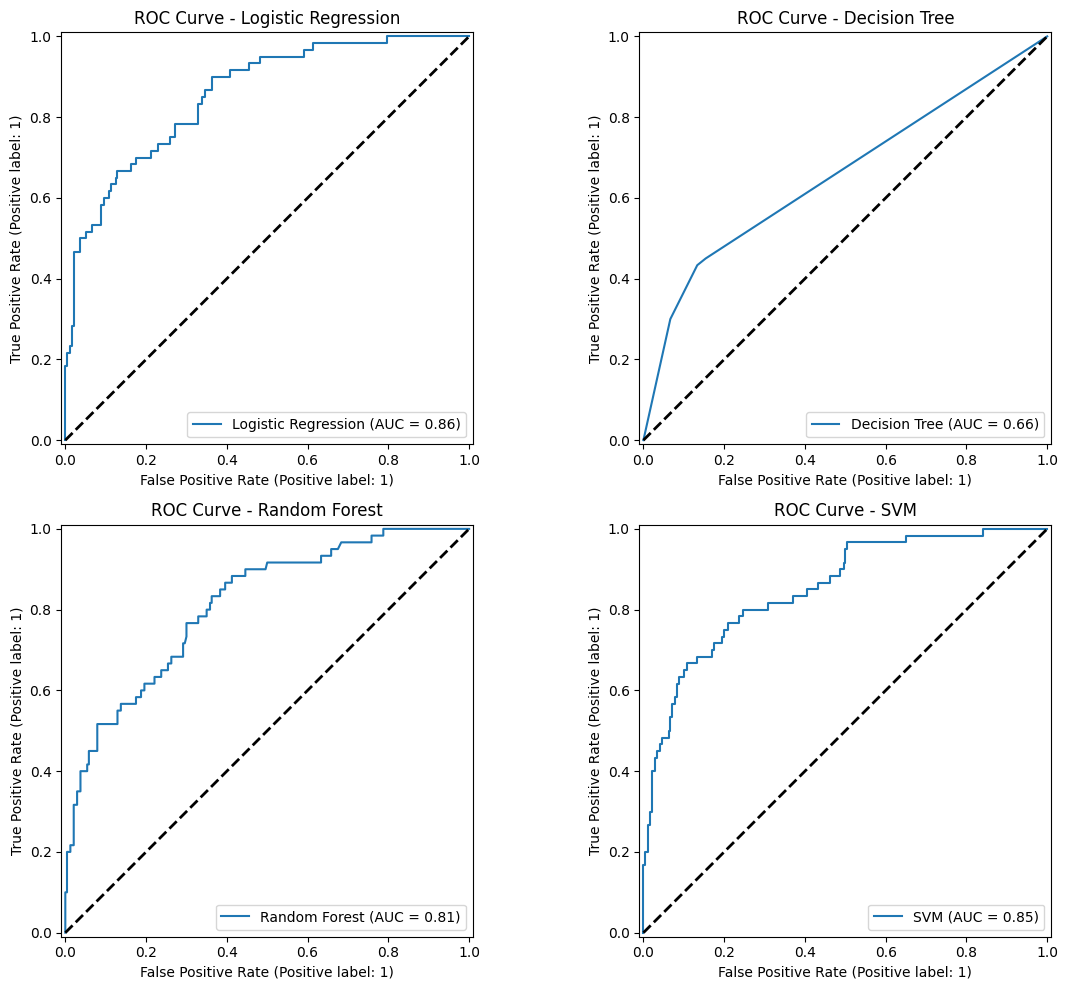

In [26]:
from sklearn.multiclass import OneVsRestClassifier
from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_auc_score, RocCurveDisplay
import matplotlib.pyplot as plt

# Binarize the multiclass target
y_test_bin = label_binarize(y_test, classes=np.unique(y_test))

# Prepare models with OneVsRest for multiclass
models_dict = {
    "Logistic Regression": OneVsRestClassifier(LogisticRegression(max_iter=1000, random_state=42)).fit(X_train, y_train),
    "Decision Tree": OneVsRestClassifier(DecisionTreeClassifier(random_state=43)).fit(X_train, y_train),
    "Random Forest": OneVsRestClassifier(RandomForestClassifier(random_state=74)).fit(X_train, y_train),
    "SVM": OneVsRestClassifier(SVC(probability=True, random_state=86)).fit(X_train, y_train)
}

fig, axes = plt.subplots(2, 2, figsize=(12, 10))
axes = axes.ravel()  # Flatten 2x2 array for easy indexing

for idx, (name, model) in enumerate(models_dict.items()):
    y_score = model.predict_proba(X_test)
    RocCurveDisplay.from_predictions(
        y_test_bin.ravel(), 
        y_score.ravel(), 
        name=name,
        ax=axes[idx]  # plot on the specific subplot
    )
    axes[idx].plot([0, 1], [0, 1], "k--", lw=2)
    axes[idx].set_title(f"ROC Curve - {name}")

plt.tight_layout()
plt.show()



In [33]:
# Add AUC to the results
for res_dict, (name, model) in zip(results, models_dict.items()):
    y_score = model.predict_proba(X_test)
    res_dict["AUC"] = roc_auc_score(y_test_bin, y_score, average='micro')

# Convert to DataFrame and sort
results_df = pd.DataFrame(results)
results_df = results_df.sort_values(by="f1_score", ascending=False)  # match key name
results_df.reset_index(drop=True, inplace=True)

print(results_df)


                  Name  f1_score  accuracy_score  precision_score    recall  \
0  Logistic Regression  0.579904        0.583333         0.582639  0.583333   
1                  SVC  0.566675        0.583333         0.557608  0.583333   
2        Random Forest  0.496154        0.500000         0.493750  0.500000   
3        Decision Tree  0.449289        0.416667         0.496071  0.416667   

        AUC  
0  0.855903  
1  0.853333  
2  0.811944  
3  0.656875  
